In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Results from all images



In [6]:
stats = pd.read_csv("final_data_output_stats_report.txt", sep=' ', header= None)

#mean dist of image 31
xmc_mean = pd.read_csv("im32_data_array_x.txt", sep=' ', header= None)

stats.columns= ["name", "x_mean", "x_mean_std", "x_std_mean", "y_mean", "y_mean_std", "y_std_mean", "x_mean_in_mm", "x_std_in_mm", "y_mean_in_mm", "y_std_in_mm"]

In [7]:
x_pics =  np.arange(6-6,56-6)
scale = 5/41 #1 pixel in mm

#need to convert std of the mean to mm
stats["x_mean_std_mm"] = stats["x_mean_std"]*scale

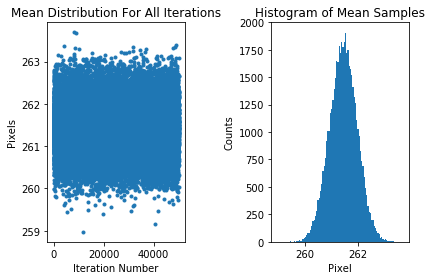

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(xmc_mean[0], marker='.', linewidth=0)
ax1.hist(xmc_mean[0], bins=100)
#ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))


ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of Mean Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("Mean Distribution For All Iterations")

plt.tight_layout()
plt.savefig("im32_x_mean_hist", dpi = 300)

In [9]:
#dispersion
disp = 1363 #mm/dB/B


## meand and std (no error saved on std), both in pixels

In [10]:
2*stats["x_mean_std"] + 0.5

0     1.216076
1     1.185909
2     1.165359
3     1.202915
4     1.208716
5     1.258725
6     1.234706
7     1.255297
8     1.149256
9     1.182808
10    1.281155
11    1.257093
12    1.374184
13    1.244689
14    1.197826
15    1.308345
16    1.403215
17    1.404035
18    1.523063
19    1.467708
20    1.369519
21    1.367508
22    1.407714
23    1.444267
24    1.564786
25    1.445113
26    1.537435
27    1.396360
28    1.488793
29    1.493685
30    1.424248
31    1.337326
32    1.238599
33    1.278933
34    1.231033
35    1.228112
36    1.328462
37    1.311544
38    1.379671
39    1.389441
40    1.304806
41    1.383362
42    1.456522
43    1.452387
44    1.405179
45    1.476773
46    1.384550
47    1.382017
48    1.393318
49    1.483801
Name: x_mean_std, dtype: float64

Text(0, 0.5, 'Pixels')

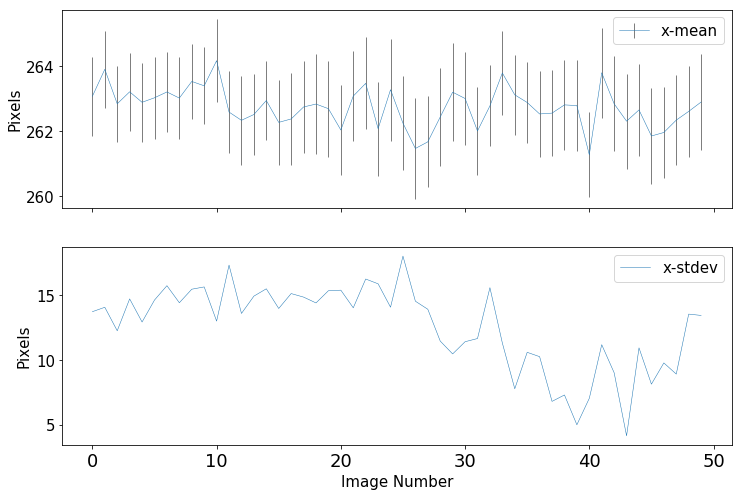

In [55]:
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True,figsize=(12,8))
ax = axs[0]
ax1= axs[1]

ax.errorbar(x_pics, stats['x_mean'], yerr =2*stats["x_mean_std"] + 0.5, linewidth=0.5, ecolor='black', capthick=2, label="x-mean")
ax.legend()

ax1.errorbar(x_pics, stats['x_std_mean'], linewidth=0.5, ecolor='black', capthick=2, label='x-stdev')
ax1.legend()

ax1.set_xlabel("Image Number")
ax1.set_ylabel("Pixels")
ax.set_ylabel("Pixels")

#plt.savefig("x_mean_stdev_allim", dpi = 300)

In [56]:
import matplotlib as mlt

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 15}

mlt.rc('font', **font)

## mean in mm (top) and mean in dispersion (bottom) with mean_std

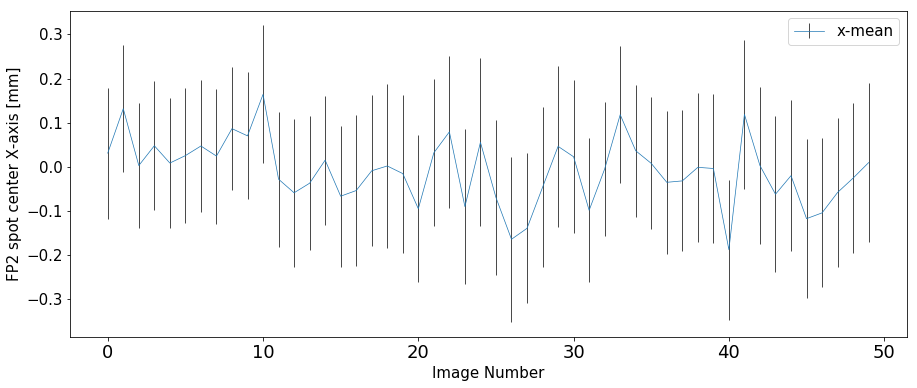

In [85]:
fig = plt.figure(figsize=(15,6))

plt.errorbar(x_pics, stats['x_mean_in_mm']-32.05, yerr =(2*stats["x_mean_std_mm"]+0.5*scale), linewidth=0.7, ecolor='black', capthick=1, label="x-mean")
plt.legend()

plt.xlabel("Image Number")
plt.ylabel("FP2 spot center X-axis [mm]")

#make labels easier to read
#reset image number


plt.savefig("FP2_stability_x_axis", dpi = 300)